# Wykorzystanie rozkładów macierzy do rozwiązywania oznaczonych układów równań

Poznane na wykładzie rozkłady (faktoryzacje) macierzy możemy wykorzystać do rozwiązywania układów równań liniowych. Dzięki wykorzystaniu specjalnych własności macierzy występujących w rozkładzie jesteśmy w stanie w łatwiejszy sposób odwrócić macierz i tym samym zminimalizować błąd.


**Zadanie 1.**

Rozważmy układ równań $Ax=b$, w którym:
* $A$ jest macierzą Hilberta o wymiarach 15x15.
* $A$ jest macierzą wartości losowych z przedziału $[0,100]$ o wymiarach 100x100,  1000x1000 i 1000000x1000000.
* $b$ jest wektorem wartości losowych, odpowiednio, o wymiarach 15x1, 100x1, 1000x1 i 1000000x1.

1. Oblicz współczynnik uwarunkowania macierzy $A$ i oceń jej uwarunkowanie.
2. Rozwiąż układ równań następującymi metodami:
    * z użyciem jawnej odwrotności $A$.
    * korzystając z rozkładu [LU](https://docs.scipy.org/doc/scipy/reference/generated/scipy.linalg.lu.html) (uwaga na macierz permutacji!):
        * z wykorzystaniem odwrotności L i U.
        * z użyciem jedynie odwrotności i metody podstawiania wstecznego.
    * korzystając z rozkładu [QR](https://numpy.org/doc/stable/reference/generated/numpy.linalg.qr.html):
        * z wykorzystaniem odwrotności Q i R.
        * z użyciem jedynie odwrotności Q i metody podstawiania wstecznego.
    * za pomocą jednej z metod iteracyjnych z poprzedniego ćwiczenia.
    * za pomocą metody [`solve`](https://numpy.org/doc/stable/reference/generated/numpy.linalg.solve.html) z pakietu NumPy.
3. Porównaj otrzymane wyniki. W tym celu oblicz normy z residuuów otrzymanych dla każdego z rozwiązań. Którą z metod cechuje najwyższa dokladność?
4. Przeprowadź porównanie wydajności ww. metod. Zmierz czas wykonania każdej metody. Aby otrzymać bardziej sensowny wynik należy powtórzyć obliczenia w pętli (np. 100 lub 1000 razy) i uśrednić wynik. Do pomiaru czasu wykonania możesz wykorzystać pakiet `time`.
Wskazówka: Do rozwiązania układu z macierzą trójkątną możesz wykorzystać funkcję [`scipy.linalg.solve_triangular`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.linalg.solve_triangular.html).

        
        


In [ ]:
import numpy as np
import scipy.linalg as la
import time

def solve_with_inverse(A, b):
    A_inv = np.linalg.inv(A)
    return A_inv @ b

def solve_with_LU_inverse(A, b):
    P, L, U = la.lu(A)
    Pb = P.T @ b
    L_inv = np.linalg.inv(L)
    y = L_inv @ Pb
    U_inv = np.linalg.inv(U)
    return U_inv @ y

def solve_with_LU_triangular(A, b):
    P, L, U = la.lu(A)
    Pb = P.T @ b
    y = la.solve_triangular(L, Pb, lower=True)
    x = la.solve_triangular(U, y, lower=False)
    return x

def solve_with_QR_inverse(A, b):
    Q, R = np.linalg.qr(A)
    Q_inv = Q.T  
    R_inv = np.linalg.inv(R)
    return R_inv @ Q_inv @ b

def solve_with_QR_triangular(A, b):
    Q, R = np.linalg.qr(A)
    Qt_b = Q.T @ b
    x = la.solve_triangular(R, Qt_b, lower=False)
    return x

def solve_gauss_seidel(A, b, tol=1e-10, max_iter=200):
    n = len(b)
    x = np.zeros(n)
    for _ in range(max_iter):
        x_new = x.copy()
        for i in range(n):
            if A[i, i] == 0:
                return x_new
            s1 = np.dot(A[i, :i], x_new[:i])
            s2 = np.dot(A[i, i+1:], x[i+1:])
            x_new[i] = (b[i] - s1 - s2) / A[i, i]
        
        if np.any(np.isnan(x_new)) or np.any(np.isinf(x_new)):
            return x_new
            
        if np.linalg.norm(x_new - x) < tol:
            return x_new
        x = x_new
    return x

def solve_numpy(A, b):
    return np.linalg.solve(A, b)

def run_zadanie1():
    print("\nMacierz Hilberta 15x15:")
    n = 15
    A_hilbert = la.hilbert(n)
    b_hilbert = np.random.rand(n)

    cond = np.linalg.cond(A_hilbert)
    print(f"Współczynnik uwarunkowania: {cond:.4e}")
    if cond > 1e12:
        print("Ocena: macierz bardzo źle uwarunkowana (cond >> 10^12).")
    elif cond > 1e6:
        print("Ocena: macierz źle uwarunkowana.")
    else:
        print("Ocena: macierz dobrze uwarunkowana.")

    methods = {
        "Jawna odwrotność":      solve_with_inverse,
        "LU (odwrotności)":      solve_with_LU_inverse,
        "LU (podstawianie)":     solve_with_LU_triangular,
        "QR (odwrotności)":      solve_with_QR_inverse,
        "QR (podstawianie)":     solve_with_QR_triangular,
        "Gauss-Seidel":          solve_gauss_seidel,
        "numpy.solve":           solve_numpy,
    }

    print(f"\n{'Metoda':<25} {'||r|| = ||Ax - b||':>22}")
    print("-" * 50)
    for name, method in methods.items():
        try:
            x = method(A_hilbert, b_hilbert)
            residual = np.linalg.norm(A_hilbert @ x - b_hilbert)
            print(f"{name:<25} {residual:>22.6e}")
        except Exception as e:
            print(f"{name:<25} Błąd: {e}")

    print("\nMacierze losowe (diagonalnie dominujące):")
    sizes = [100, 1000]
    for n in sizes:
        A_rand = np.random.uniform(0, 100, (n, n))
        A_rand += np.diag(np.sum(np.abs(A_rand), axis=1))
        
        b_rand = np.random.rand(n)
        cond = np.linalg.cond(A_rand)
        print(f"\nRozmiar {n}x{n}, cond = {cond:.4e}")

        print(f"{'Metoda':<25} {'||r||':>22} {'Czas [ms]':>12}")
        print("-" * 62)

        for name, method in methods.items():
            if name == "Gauss-Seidel" and n >= 1000:
                print(f"{name:<25} {'(pominięto – za wolna)':>22}")
                continue
            try:
                repeats = 1 if name == "Gauss-Seidel" else (10 if n <= 100 else 3)
                
                t0 = time.time()
                for _ in range(repeats):
                    x = method(A_rand, b_rand)
                elapsed_ms = (time.time() - t0) / repeats * 1000
                residual = np.linalg.norm(A_rand @ x - b_rand)
                print(f"{name:<25} {residual:>22.6e} {elapsed_ms:>11.3f}")
            except Exception as e:
                print(f"{name:<25} Błąd: {e}")

if __name__ == "__main__":
    run_zadanie1()


Macierz Hilberta 15x15:
Współczynnik uwarunkowania: 7.3638e+17
Ocena: macierz bardzo źle uwarunkowana (cond >> 10^12).

Metoda                        ||r|| = ||Ax - b||
--------------------------------------------------
Jawna odwrotność                    3.805583e+00
LU (odwrotności)                    2.821057e+00
LU (podstawianie)                   3.539768e+00
QR (odwrotności)                    5.410811e+00
QR (podstawianie)                   1.355071e+01
Gauss-Seidel                        8.795143e-01
numpy.solve                         2.829317e+00

Macierze losowe (diagonalnie dominujące):

Rozmiar 100x100, cond = 2.3164e+00
Metoda                                     ||r||    Czas [ms]
--------------------------------------------------------------
Jawna odwrotność                    3.317082e-15       0.237
LU (odwrotności)                    2.330560e-15       0.514
LU (podstawianie)                   2.132940e-15       0.211
QR (odwrotności)                    3.407753e-15 

# Interpolacja

**Zadanie 2.**

Przeprowadź interpolacje poniższych funkcji $f(x)$ za pomocą wielomianów interpolacyjnych Lagrange'a ([`scipy.interpolate.lagrange`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.interpolate.lagrange.html)). Stwórz wykresy funkcji interpolacyjnych i zaznacz na nich punkty, w ktorych dokonano oceny wartości funkcji.

Pierwsza funkcja:

* $f(0) = 1$,
* $f(0.25) = 1.64872$,
* $f(0.5) = 2.71828$,
* $f(0.75) = 4.48169.$

Oblicz $f(0.43)$.

Druga funkcja:

* $f_2(0.1) = 0.62049958$,
* $f_2(0.2) = -0.28398668$,
* $f_2(0.3) = 0.00660095$,
* $f_2(0.4) = 0.24842440$. 

Oblicz $f_2(0.25)$.

Pierwsza funkcja:
Wyznaczony wielomian:
       3         2
2.912 x + 1.183 x + 2.117 x + 1
Obliczone f(0.43) = 2.360605

Druga funkcja:
Wyznaczony wielomian:
        3         2
-207.3 x + 184.1 x - 49.77 x + 3.964
Obliczone f2(0.25) = -0.210337


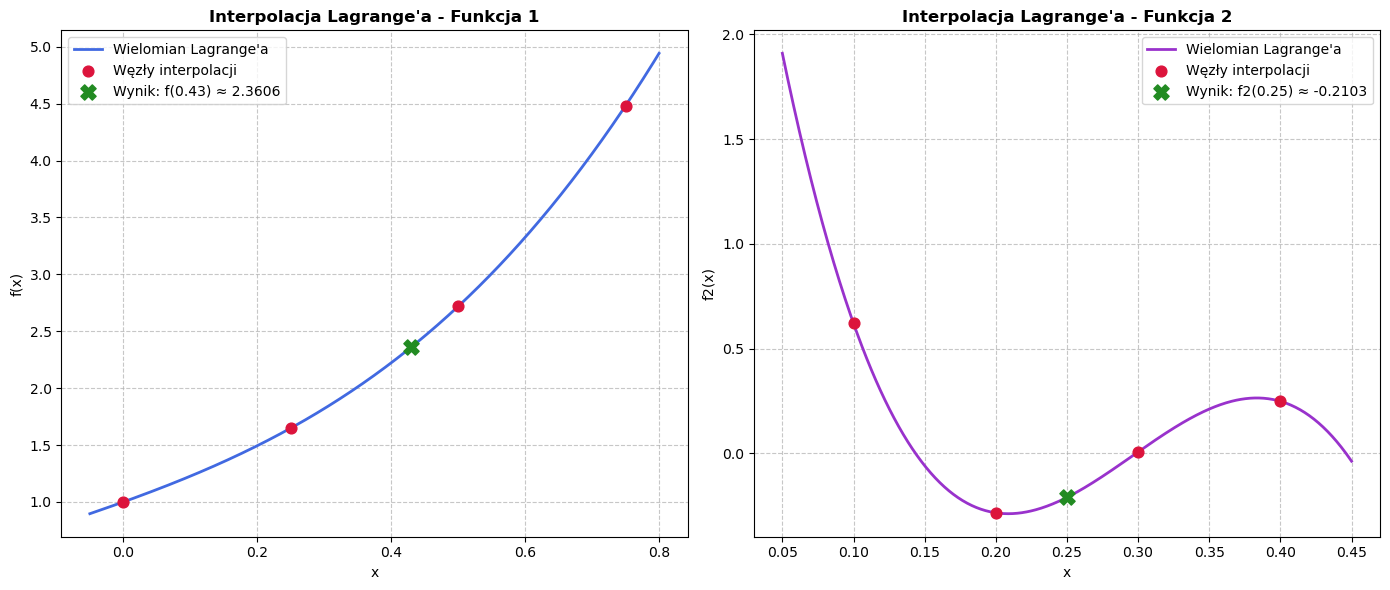

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import lagrange

def interpolacja_zadanie():
    x1 = np.array([0.0, 0.25, 0.5, 0.75])
    y1 = np.array([1.0, 1.64872, 2.71828, 4.48169])
    szukany_x1 = 0.43
    wielomian1 = lagrange(x1, y1)
    wynik1 = wielomian1(szukany_x1)

    print("Pierwsza funkcja:")
    print(f"Wyznaczony wielomian:\n{wielomian1}")
    print(f"Obliczone f({szukany_x1}) = {wynik1:.6f}\n")

    x2 = np.array([0.1, 0.2, 0.3, 0.4])
    y2 = np.array([0.62049958, -0.28398668, 0.00660095, 0.24842440])
    szukany_x2 = 0.25
    wielomian2 = lagrange(x2, y2)
    wynik2 = wielomian2(szukany_x2)

    print("Druga funkcja:")
    print(f"Wyznaczony wielomian:\n{wielomian2}")
    print(f"Obliczone f2({szukany_x2}) = {wynik2:.6f}")

    plt.figure(figsize=(14, 6))

    plt.subplot(1, 2, 1)
    x1_geste = np.linspace(-0.05, 0.8, 500)
    plt.plot(x1_geste, wielomian1(x1_geste), color='royalblue', label='Wielomian Lagrange\'a', linewidth=2)
    plt.scatter(x1, y1, color='crimson', s=60, zorder=5, label='Węzły interpolacji')
    plt.scatter(szukany_x1, wynik1, color='forestgreen', marker='X', s=120, zorder=6, 
                label=f'Wynik: f({szukany_x1}) ≈ {wynik1:.4f}')
    plt.title('Interpolacja Lagrange\'a - Funkcja 1', fontsize=12, fontweight='bold')
    plt.xlabel('x')
    plt.ylabel('f(x)')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(loc='upper left')

    plt.subplot(1, 2, 2)
    x2_geste = np.linspace(0.05, 0.45, 500)
    plt.plot(x2_geste, wielomian2(x2_geste), color='darkorchid', label='Wielomian Lagrange\'a', linewidth=2)
    plt.scatter(x2, y2, color='crimson', s=60, zorder=5, label='Węzły interpolacji')
    plt.scatter(szukany_x2, wynik2, color='forestgreen', marker='X', s=120, zorder=6, 
                label=f'Wynik: f2({szukany_x2}) ≈ {wynik2:.4f}')
    plt.title('Interpolacja Lagrange\'a - Funkcja 2', fontsize=12, fontweight='bold')
    plt.xlabel('x')
    plt.ylabel('f2(x)')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(loc='upper right')

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    interpolacja_zadanie()

***Zadanie 3.***

Rozważmy funkcję $f(x)=\frac{1}{25x^2+1}$. 

Przeprowadź interpolacje funkcji $f$ w przedziale $[-2,2]$ wielomianem Lagrange'a oraz funkcjami sklejanymi 3 stopnia w:
- 21 równoodległych węzłach,
- 21 węzłach [Czebyszewa](https://pl.wikipedia.org/wiki/Węzły_Czebyszewa).

**Wskazówka** Interpolację funkcjami sklejanymi możesz przeprowadzić za pomocą funkcji [`interp1d`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.interpolate.interp1d.html#scipy.interpolate.interp1d).

Umieść wielomian interpolacyjny, oryginalną funkcję $f$ oraz węzly interpolacyjne na wspólnym wykresie (jeden wykres dla metody Lagrange'a oraz jeden dla funkcji sklejanych). Porównaj otrzymane rezultaty. Przeprowadź te same działania dla przedziału $x\in[-5,5]$. Jakie problemy możesz zauważyć na otrzymanych wykresach?


Generowanie wykresów dla przedziału [-2, 2]...


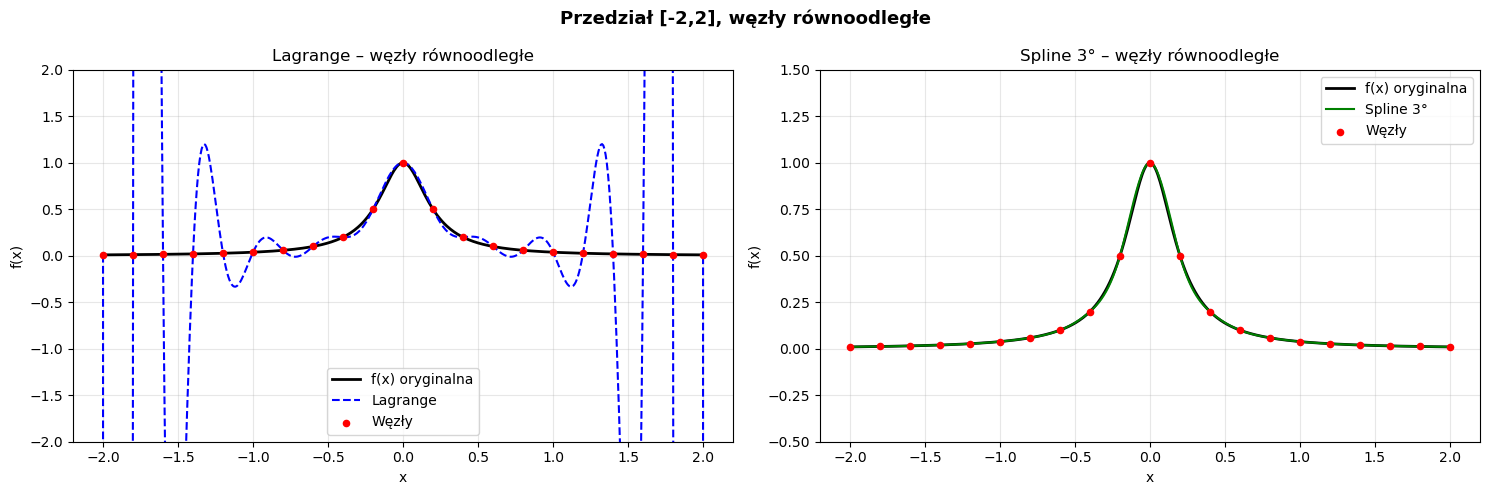

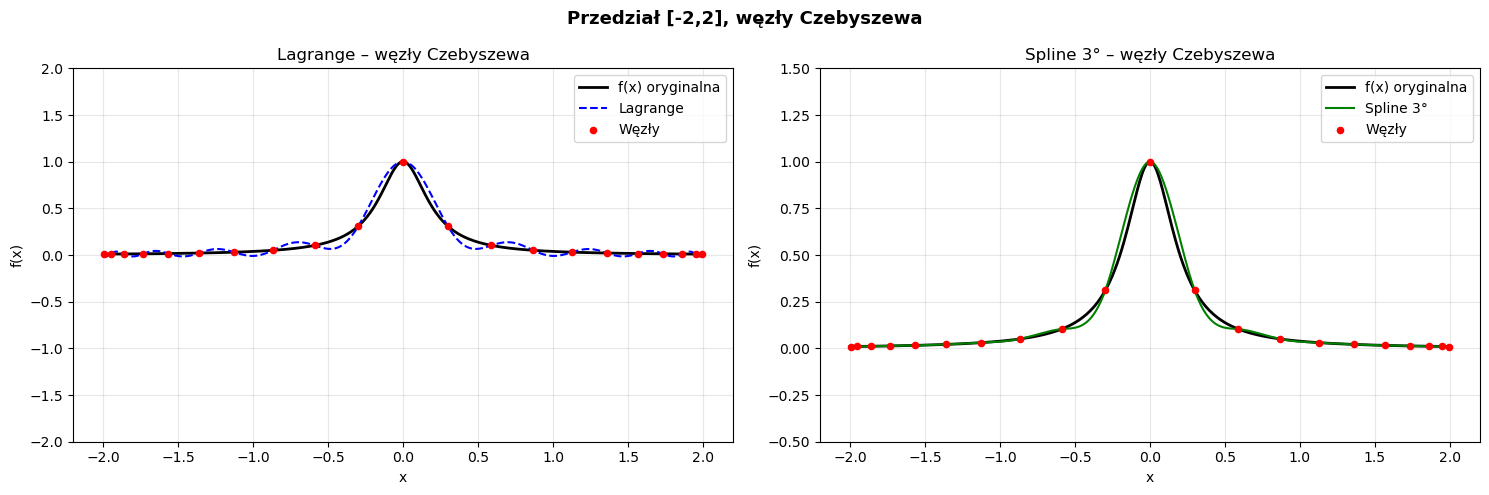


Generowanie wykresów dla przedziału [-5, 5]...


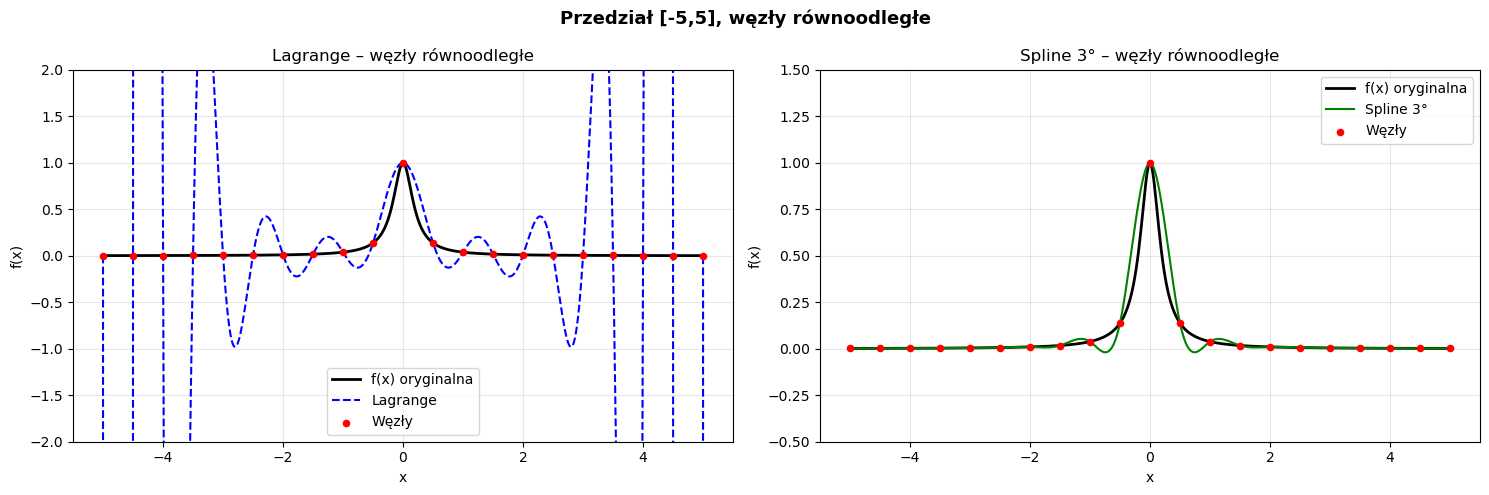

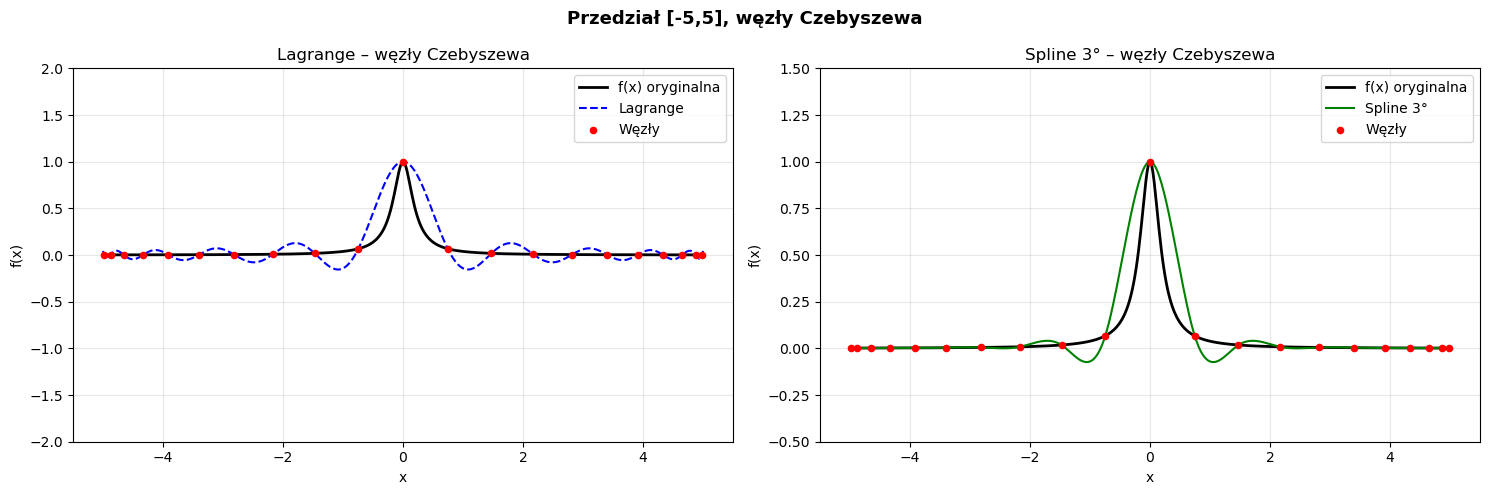


Obserwacje:
- Lagrange (równoodległe): Gigantyczne oscylacje na końcach (Efekt Rungego).
- Lagrange (Czebyszew): Oscylacje są minimalizowane dzięki zagęszczeniu węzłów na krańcach.
- Spline 3°: Najstabilniejsza metoda, brak efektu Rungego.


In [2]:
import numpy as np
import scipy.linalg as la
from scipy.interpolate import lagrange, interp1d
import matplotlib.pyplot as plt

def chebyshev_nodes(a, b, n):
    k = np.arange(1, n + 1)
    x_cheb = np.cos((2*k - 1) / (2*n) * np.pi)
    return 0.5 * (a + b) + 0.5 * (b - a) * x_cheb

def run_zadanie3():
    def f(x):
        return 1 / (25 * x**2 + 1)
    n_nodes = 21  

    for a, b in [(-2, 2), (-5, 5)]:
        print(f"\nGenerowanie wykresów dla przedziału [{a}, {b}]...")
        x_plot = np.linspace(a, b, 500)
        y_true = f(x_plot)
        x_eq = np.linspace(a, b, n_nodes)
        x_ch = chebyshev_nodes(a, b, n_nodes)

        for nodes, label in [(x_eq, "równoodległe"), (x_ch, "Czebyszewa")]:
            y_nodes = f(nodes)

            poly = lagrange(nodes, y_nodes)
            y_lagrange = poly(x_plot)

            spline = interp1d(nodes, y_nodes, kind='cubic', fill_value='extrapolate')
            y_spline = spline(x_plot)

            fig, axes = plt.subplots(1, 2, figsize=(15, 5))
            fig.suptitle(f"Przedział [{a},{b}], węzły {label}", fontsize=13, fontweight='bold')

            axes[0].plot(x_plot, y_true, 'k-', linewidth=2, label='f(x) oryginalna')
            axes[0].plot(x_plot, y_lagrange, 'b--', linewidth=1.5, label='Lagrange')
            axes[0].scatter(nodes, y_nodes, color='red', zorder=5, s=20, label='Węzły')

            axes[0].set_ylim(-2, 2)
            axes[0].set_title(f"Lagrange – węzły {label}")
            axes[0].set_xlabel("x")
            axes[0].set_ylabel("f(x)")
            axes[0].legend()
            axes[0].grid(True, alpha=0.3)

            axes[1].plot(x_plot, y_true, 'k-', linewidth=2, label='f(x) oryginalna')
            axes[1].plot(x_plot, y_spline, 'g-', linewidth=1.5, label='Spline 3°')
            axes[1].scatter(nodes, y_nodes, color='red', zorder=5, s=20, label='Węzły')
            axes[1].set_ylim(-0.5, 1.5)
            axes[1].set_title(f"Spline 3° – węzły {label}")
            axes[1].set_xlabel("x")
            axes[1].set_ylabel("f(x)")
            axes[1].legend()
            axes[1].grid(True, alpha=0.3)

            plt.tight_layout()
            plt.show()

    print("\nObserwacje:")
    print("- Lagrange (równoodległe): Gigantyczne oscylacje na końcach (Efekt Rungego).")
    print("- Lagrange (Czebyszew): Oscylacje są minimalizowane dzięki zagęszczeniu węzłów na krańcach.")
    print("- Spline 3°: Najstabilniejsza metoda, brak efektu Rungego.")

if __name__ == "__main__":
    run_zadanie3()



***Zadanie 4.***

Kierowca jadący z miasta A do miasta B, zauważywszy na drodze fotoradar, zaczął gwałtownie hamować. Przebieg jego położenia, zarejestrowany przez nawigację, pokazano w poniższej tabeli. Wiedząc, że radar znajduje się w punkcie o współrzędnej 79.6 m, oszacuj kiedy kierowca minął fotoradar (w tym celu skorzystaj z jednej z metod z laboratorium 3) oraz z jaką prędkością wtedy jechał (wykorzystaj relację drogi i prędkości znaną z fizyki). 

|czas \[s\]|położenie \[m\]|
|--|--|
|0.0|0.0|
|1.0|42.7|
|2.0|73.2|
|3.0|92.5|

Czas minięcia fotoradaru: t ≈ 2.275847 s
Prędkość przy fotoradarze: v ≈ 21.6819 m/s = 78.05 km/h


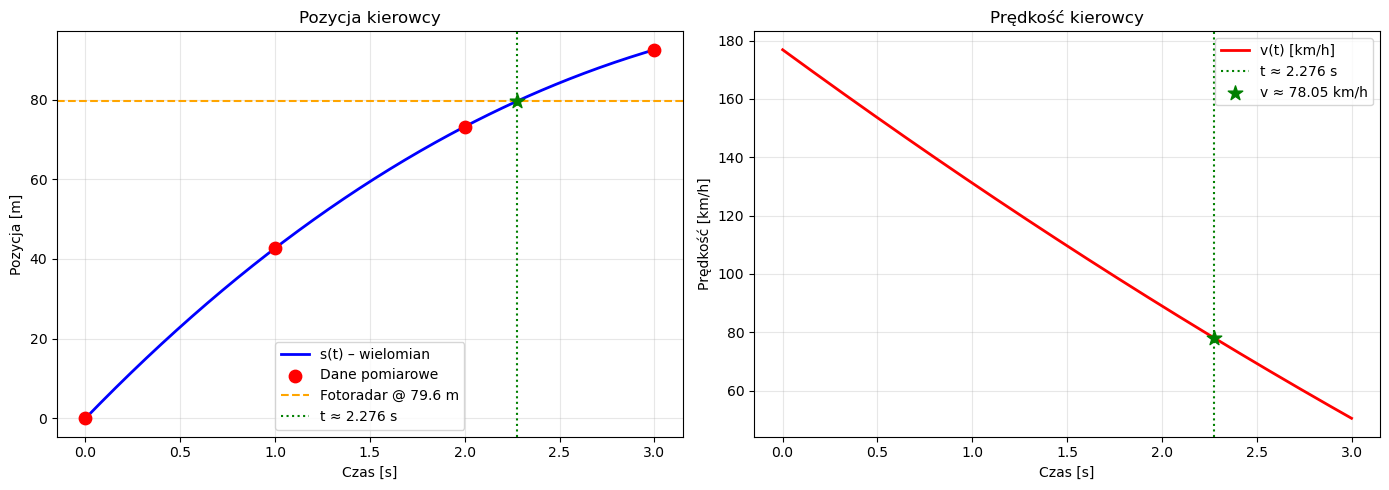

Wykres zapisano jako: zadanie4_fotoradar.png


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import lagrange

def run_zadanie4():
    t_data = np.array([0.0, 1.0, 2.0, 3.0])
    s_data = np.array([0.0, 42.7, 73.2, 92.5])
    radar_pos = 79.6  # [m]
    poly_s = lagrange(t_data, s_data)

    def equation(t):
        return poly_s(t) - radar_pos

    def bisection(f, a, b, tol=1e-10, max_iter=1000):
        assert f(a) * f(b) < 0, "Funkcja musi mieć różne znaki na końcach"
        for _ in range(max_iter):
            mid = (a + b) / 2
            if abs(f(mid)) < tol or (b - a) / 2 < tol:
                return mid
            if f(a) * f(mid) < 0:
                b = mid
            else:
                a = mid
        return (a + b) / 2

    t_a, t_b = 1.5, 2.5   
    t_radar = bisection(equation, t_a, t_b)
    print(f"Czas minięcia fotoradaru: t ≈ {t_radar:.6f} s")

    poly_v = np.polyder(poly_s)
    v_radar = poly_v(t_radar)
    print(f"Prędkość przy fotoradarze: v ≈ {v_radar:.4f} m/s = {v_radar * 3.6:.2f} km/h")

    t_plot = np.linspace(0, 3, 300)
    s_plot = poly_s(t_plot)
    v_plot = poly_v(t_plot)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(t_plot, s_plot, 'b-', linewidth=2, label='s(t) – wielomian')
    axes[0].scatter(t_data, s_data, color='red', s=80, zorder=5, label='Dane pomiarowe')
    axes[0].axhline(radar_pos, color='orange', linestyle='--', linewidth=1.5,
                    label=f'Fotoradar @ {radar_pos} m')
    axes[0].axvline(t_radar, color='green', linestyle=':', linewidth=1.5,
                    label=f't ≈ {t_radar:.3f} s')
    axes[0].scatter([t_radar], [radar_pos], color='green', s=120, zorder=6, marker='*')
    axes[0].set_title("Pozycja kierowcy")
    axes[0].set_xlabel("Czas [s]")
    axes[0].set_ylabel("Pozycja [m]")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(t_plot, v_plot * 3.6, 'r-', linewidth=2, label="v(t) [km/h]")
    axes[1].axvline(t_radar, color='green', linestyle=':', linewidth=1.5,
                    label=f't ≈ {t_radar:.3f} s')
    axes[1].scatter([t_radar], [v_radar * 3.6], color='green', s=120, zorder=5,
                    marker='*', label=f'v ≈ {v_radar*3.6:.2f} km/h')
    axes[1].set_title("Prędkość kierowcy")
    axes[1].set_xlabel("Czas [s]")
    axes[1].set_ylabel("Prędkość [km/h]")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("zadanie4_fotoradar.png", dpi=120, bbox_inches='tight')
    plt.show()
    print("Wykres zapisano jako: zadanie4_fotoradar.png")

if __name__ == "__main__":
    run_zadanie4()

**Zadanie dla zainteresowanych programowaniem funkcyjnym w Pythonie**

Stwórz funkcję znajdującą wielomian interpolacyjny metodą Lagrange'a. Funkcja powinna przyjmować dwie listy:
* listę argumentów ($x$-ów)
* listę wartości ($y$-ów).  


Po wykonaniu obliczeń funkcja powinna zwracać wielomian w postaci obiektu typu **funkcja** (a nie `numpy.Polynomial`).

**Wskazówka** Wykorzystaj wyrażenia *lambda*. Dla ułatwienia możesz się też posłużyć pakietami `operator` i `functools`.
